In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import sys
import jax.numpy as jnp
import jax
import json
import os

from nrt.helpers import encode
from nrt.data import TrajectoryGenerator


In [2]:
filepath = '../data/260129/decay/run000'
counter = 3
save_fig = 0
plot_scale = 1

if counter == '':
    adding_string = ''
else:
    adding_string = '_'

%cd "$filepath"

# Load parameters
with open('parameters.json', 'r') as json_file:
    parameters = json.load(json_file)

# Load g0 (activity at origin) instead of W
with open('g0' + adding_string + f'{counter}.pkl', 'rb') as pickle_file:
    g0 = pickle.load(pickle_file)

# Load frequencies
with open('om'+ adding_string + f'{counter}.pkl', 'rb') as pickle_file:
    om = pickle.load(pickle_file)

# Load transformation matrix S
with open('S'+ adding_string + f'{counter}.pkl', 'rb') as pickle_file:
    S = pickle.load(pickle_file)

# Load losses
with open('min_L'+ adding_string + f'{counter}.pkl', 'rb') as pickle_file:
    min_L = pickle.load(pickle_file)

with open('L'+ adding_string + f'{counter}.pkl', 'rb') as pickle_file:
    L = pickle.load(pickle_file)

# Load initial values
with open('g0_init'+ adding_string + f'{counter}.pkl', 'rb') as pickle_file:
    g0_init = pickle.load(pickle_file)

with open('S_init'+ adding_string + f'{counter}.pkl', 'rb') as pickle_file:
    S_init = pickle.load(pickle_file)

# Load final values
try:
    with open('g0_final'+ adding_string + f'{counter}.pkl', 'rb') as pickle_file:
        g0_final = pickle.load(pickle_file)
except:
    g0_final = g0

try:
    with open('S_final'+ adding_string + f'{counter}.pkl', 'rb') as pickle_file:
        S_final = pickle.load(pickle_file)
except:
    S_final = S

# Use final values if min loss is poor
# if min_L[0] < 1:
#     g0 = g0_final
#     S = S_final

# Compute D from g0 shape
D = g0.shape[0]
M = int((D - 1) / 2)

print(f"Loaded optimization results:")
print(f"  D = {D}, M = {M}")
print(f"  g0 shape: {g0.shape}")
print(f"  S shape: {S.shape}")
print(f"  om shape: {om.shape}")
print(f"  Min loss: {min_L[1]:.5f}")

/home/julian/Projects/MasterThesis/ICLR_Actionable_Reps/data/260129/decay/run000
Loaded optimization results:
  D = 65, M = 32
  g0 shape: (65,)
  S shape: (65, 65)
  om shape: (32, 2)
  Min loss: 0.00853


## Encode 

(<Figure size 800x800 with 2 Axes>, <Axes: >)

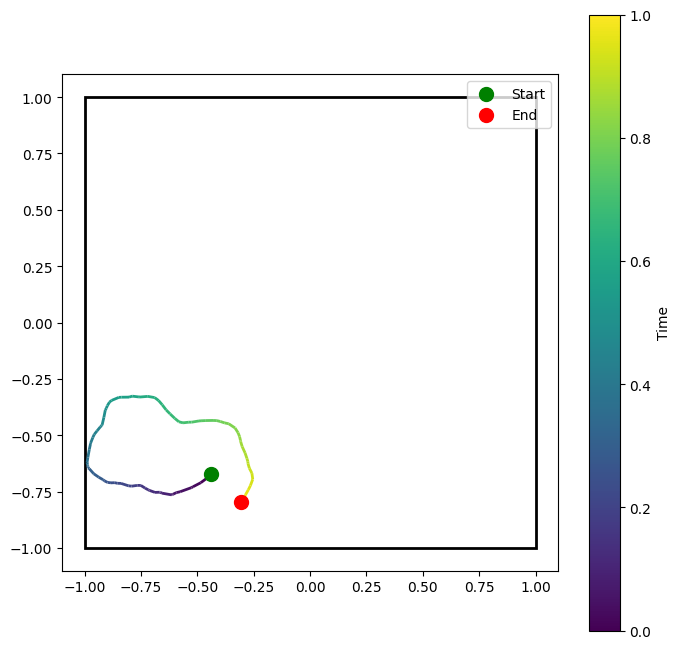

In [3]:
generator = TrajectoryGenerator()

data = jnp.asarray(generator.generate_trajectory(2, 2, 1000, 100))
representations = np.asarray(encode(g0, om, S, data))

B, L, D = representations.shape
representations = representations.reshape(B * L, D)
generator.visualize_trajectory_time(np.asarray(data[0,:,:]))

In [4]:
# Organize cells into modules
idx = np.array([1, 4, 5, 6, 7, 8, 9, 10, 15, 16, 20, 21, 23, 25, 26, 27, 28, 34, 35, 36, 37, 38, 39, 41, 42, 43, 44, 46, 48, 49, 50, 52, 54, 56, 57, 60, 61, 63, 64])
m1 = representations[:, idx]

## PCA

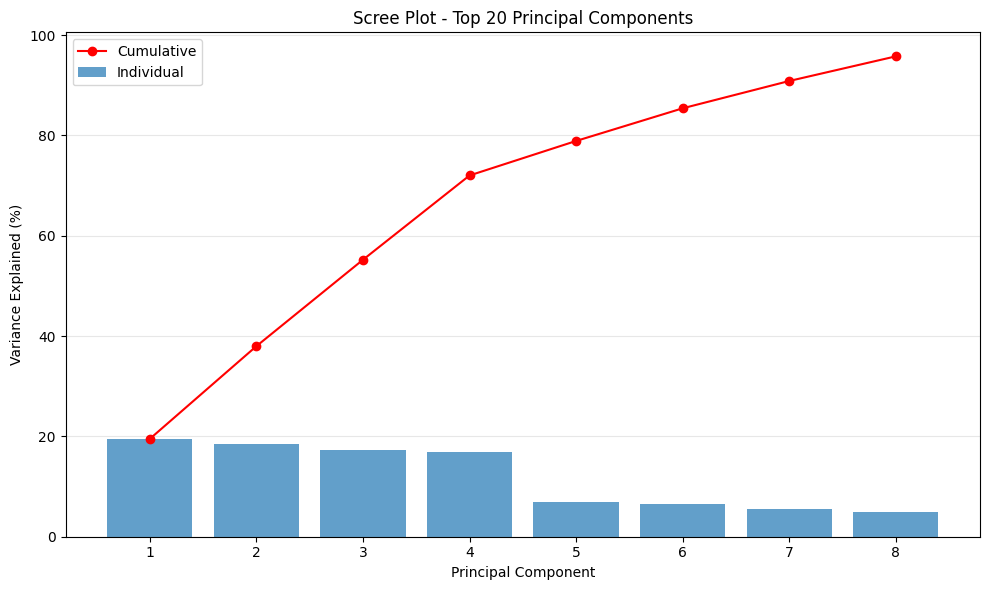

In [5]:
from sklearn.decomposition import PCA

pca = PCA(n_components=8)
pcs = pca.fit_transform(m1)

# Scree plot
fig, ax = plt.subplots(figsize=(10, 6))
pc_numbers = np.arange(1, 9)
ax.bar(pc_numbers, pca.explained_variance_ratio_ * 100, alpha=0.7, label='Individual')
ax.plot(pc_numbers, np.cumsum(pca.explained_variance_ratio_) * 100, 'ro-', label='Cumulative')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Variance Explained (%)')
ax.set_title('Scree Plot - Top 20 Principal Components')
ax.set_xticks(pc_numbers)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
import umap

reducer = umap.UMAP(
    n_components=3,
    metric='cosine',
    n_neighbors=5000,
    min_dist=0.8,
    init='spectral',
    n_jobs=24
)

embedding = reducer.fit_transform(pcs)

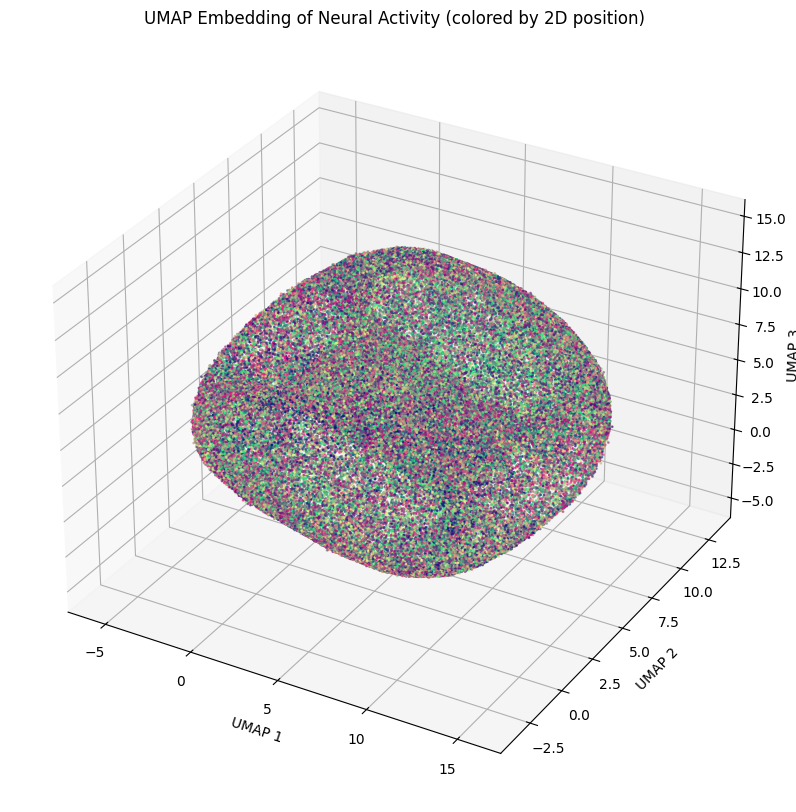

In [8]:
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Color by 2D position in original environment
positions = np.asarray(data.reshape(-1, 2))
pos_normalized = (positions - positions.min(axis=0)) / (positions.max(axis=0) - positions.min(axis=0))
pos_colors = np.zeros((len(positions), 3))
pos_colors[:, 0] = pos_normalized[:, 0]  # x -> red
pos_colors[:, 1] = pos_normalized[:, 1]  # y -> green
pos_colors[:, 2] = 0.5  # constant blue

scatter = ax.scatter(
    embedding[:, 0], 
    embedding[:, 1], 
    embedding[:, 2],
    c=pos_colors,
    s=1,
    alpha=0.6
)

ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_zlabel('UMAP 3')
ax.set_title('UMAP Embedding of Neural Activity (colored by 2D position)')
plt.show()

In [ ]:
import plotly.graph_objects as go

fig = go.Figure(
    data=[go.Scatter3d(
        x=embedding[:, 0],
        y=embedding[:, 1],
        z=embedding[:, 2],
        mode='markers',
        marker=dict(
            size=2,
            color=['rgb({},{},{})'.format(int(r*255), int(g*255), int(b*255)) 
                   for r, g, b in pos_colors],
            opacity=0.6
        )
    )]
)

fig.update_layout(
    title='UMAP Embedding (colored by 2D position)',
    scene=dict(
        xaxis_title='UMAP 1',
        yaxis_title='UMAP 2',
        zaxis_title='UMAP 3'
    )
)

fig.show()

: 